# Six analysis regions

Map the six mutually exclusive ocean regions used in the regional deoxygenation and GFDL-ESM4 analyses. Region boundaries come from the same `basin_masks.create_basin_mask(..., nbasins=6)` function used by the paper notebooks. Running the cells saves `Figures/six_analysis_regions_map.pdf`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.insert(0, '/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis/Python_functions')
import basin_masks

MODEL_FILE = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/NETCDF/Fully_sampled_models_annual_o2/o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc')
OUTPUT = Path('Figures/six_analysis_regions_map.pdf')
REGION_NAMES = ('Atlantic', 'Pacific', 'Indian', 'Southern', 'North Atlantic', 'North Pacific')
REGION_LABELS = {
    'Atlantic': 'Tropical\nAtlantic Ocean',
    'Pacific': 'Tropical\nPacific Ocean',
    'Indian': 'Tropical\nIndian Ocean',
    'Southern': 'Southern Ocean',
    'North Atlantic': 'North\nAtlantic Ocean',
    'North Pacific': 'North\nPacific Ocean',
}
REGION_COLORS = ('#4E79A7', '#59A14F', '#F28E2B', '#76B7B2', '#E15759', '#B07AA1')
REGION_LABEL_POINTS = {
    'Atlantic': (330, -7), 'Pacific': (225, -7), 'Indian': (80, -14),
    'Southern': (180, -55), 'North Atlantic': (320, 43), 'North Pacific': (190, 43),
}

/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Anaconda/envs/xmip/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
# Use the model field only to identify ocean grid cells; regional boundaries
# are defined by the shared basin_masks function.
with xr.open_dataset(MODEL_FILE) as ds:
    variable = 'o2' if 'o2' in ds.data_vars else next(iter(ds.data_vars))
    ocean = ds[variable]
    for dim in ('time', 'lev', 'depth'):
        if dim in ocean.dims:
            ocean = ocean.isel({dim: 0})
    ocean = ocean.rename({old: new for old, new in (('x', 'lon'), ('y', 'lat')) if old in ocean.dims})
    ocean = ocean.load()

masks = basin_masks.create_basin_mask(ocean.where(np.isfinite(ocean)), nbasins=6)
region = xr.full_like(masks[0], np.nan, dtype=float)
for number, mask in enumerate(masks, start=1):
    region = region.where(~(mask.fillna(0) > 0), float(number))
assert set(np.unique(region.values[np.isfinite(region.values)])) == set(range(1, 7))

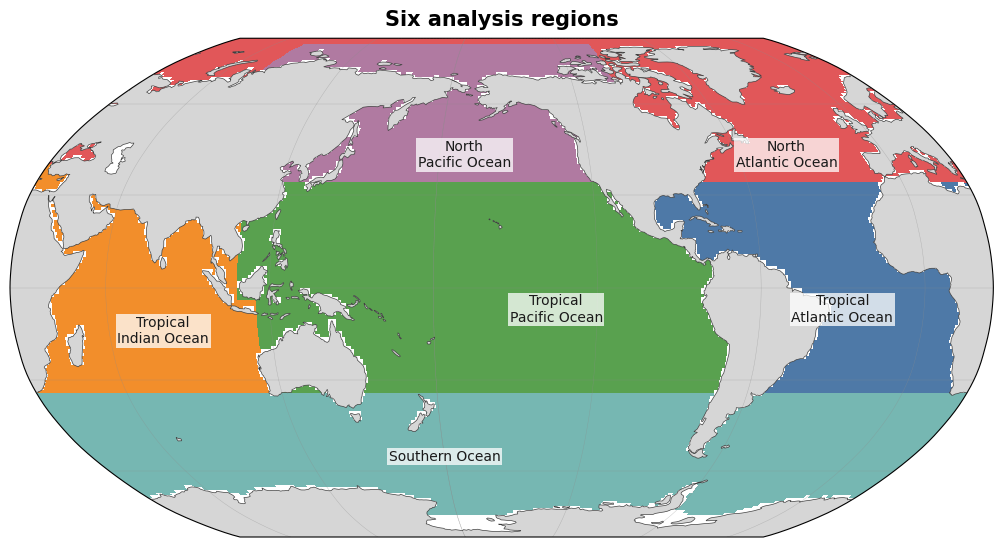

Saved Figures/six_analysis_regions_map.pdf


In [3]:
projection = ccrs.Robinson(central_longitude=205)
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection=projection)
fig.subplots_adjust(left=0.015, right=0.985, bottom=0.035, top=0.91)

cmap = ListedColormap(REGION_COLORS)
norm = BoundaryNorm(np.arange(0.5, 7.5), cmap.N)
ax.pcolormesh(region.lon, region.lat, region, cmap=cmap, norm=norm,
              shading='nearest', transform=ccrs.PlateCarree(), rasterized=True)
ax.add_feature(cfeature.LAND, facecolor='0.84', edgecolor='none', zorder=2)
ax.coastlines(linewidth=0.5, color='0.25', zorder=3)
ax.gridlines(linewidth=0.3, color='0.55', alpha=0.5)
ax.set_global()
for name in REGION_NAMES:
    lon, lat = REGION_LABEL_POINTS[name]
    ax.text(lon, lat, REGION_LABELS[name], transform=ccrs.PlateCarree(),
            ha='center', va='center', fontsize=11, color='0.1',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.2), zorder=4)
ax.set_title('Six analysis regions', fontsize=12, fontweight='bold', pad=9)

OUTPUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT, facecolor='white')
plt.show()
print(f'Saved {OUTPUT}')